In [1]:
pip install jupyterlab statsbombpy mplsoccer xgboost streamlit pandas numpy scikit-learn matplotlib seaborn

  Using cached statsbombpy-1.22.0-py3-none-any.whl.metadata (63 kB)
  Using cached mplsoccer-1.8.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached requests_cache-1.3.3-py3-none-any.whl.metadata (9.4 kB)
  Using cached inflect-7.5.0-py3-none-any.whl.metadata (24 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached typeguard-4.6.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached cattrs-26.1.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached url_normalize-3.0.0-py3-none-any.whl.metadata (7.5 kB)
Using cached statsbombpy-1.22.0-py3-none-any.whl (18 kB)
Using cached mplsoccer-1.8.0-py3-none-any.whl (108 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 6.5 MB/s eta 0:00:16
   - -------------------------------------- 3.1/101.7 MB 7.4 MB/s eta 0:00:14
   -- ------------------------------------- 5.2/101.7 MB 

In [3]:
# Cell 1: Import required libraries for data manipulation, visualization, and modeling

# Pandas: Used for tabular data manipulation and analysis (DataFrames)
import pandas as pd

# NumPy: Used for mathematical calculations (distances, angles, and trigonometry)
import numpy as np

# Matplotlib: Base library for creating charts and figures
import matplotlib.pyplot as plt

# StatsBombPy: Official API wrapper to download free football event and match data
from statsbombpy import sb

# XGBoost: Machine Learning algorithm used to build our Expected Goals (xG) model
from xgboost import XGBClassifier

# Scikit-learn (train_test_split): Splits dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Scikit-learn (metrics): Evaluates the precision and error of our xG model
from sklearn.metrics import roc_auc_score, log_loss

# Pickle: Saves the trained ML model to a file to use later in our Streamlit web app
import pickle

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Cell 2: Fetch and display available free competitions from StatsBomb

# Download the list of open competitions
competitions = sb.competitions()

display_cols = ['competition_name', 'season_name', 'competition_id', 'season_id']

competitions[display_cols].head(20)

C:\Users\jpazu\anaconda3\envs\ProjetoFutebolPredictions\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_name,season_name,competition_id,season_id
0,1. Bundesliga,2023/2024,9,281
1,1. Bundesliga,2015/2016,9,27
2,African Cup of Nations,2023,1267,107
3,Champions League,2018/2019,16,4
4,Champions League,2017/2018,16,1
5,Champions League,2016/2017,16,2
6,Champions League,2015/2016,16,27
7,Champions League,2014/2015,16,26
8,Champions League,2013/2014,16,25
9,Champions League,2012/2013,16,24


In [6]:
# Cell 3: Fetch all matches from the FIFA World Cup 2022

# Competition ID 43 = FIFA World Cup, Season ID 106 = 2022
competition_id = 43
season_id = 106

# Get all matches for this tournament
matches = sb.matches(competition_id=competition_id, season_id=season_id)

print(f"Total matches retrieved: {len(matches)}")

# Display match details (teams and scores) 
match_columns = ['match_id', 'match_date', 'home_team', 'away_team', 'home_score', 'away_score']
matches[match_columns].head(10)

C:\Users\jpazu\anaconda3\envs\ProjetoFutebolPredictions\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Total matches retrieved: 64


,match_id,match_date,home_team,away_team,home_score,away_score
0,3857276,2022-12-01,Canada,Morocco,1,2
1,3857271,2022-11-21,England,Iran,6,2
2,3857296,2022-12-01,Croatia,Belgium,0,0
3,3857274,2022-11-25,Netherlands,Ecuador,1,1
4,3857255,2022-12-01,Japan,Spain,2,1
5,3857272,2022-11-25,England,United States,0,0
6,3857278,2022-11-29,Iran,United States,0,1
7,3857277,2022-11-23,Morocco,Croatia,0,0
8,3857273,2022-11-25,Wales,Iran,0,2
9,3857275,2022-11-30,Tunisia,France,1,0


In [9]:
# Cell 4: Download all events for the FIFA World Cup 2022 and filter exclusively for Shots

# Fetch all events from the World Cup 2022 
events = sb.competition_events(
    country="International",
    division="FIFA World Cup",
    season="2022",
    gender="male"
)

# Filter the dataframe to keep only shot events
shots = events[events['type'] == 'Shot'].copy()

print(f"Total shot events retrieved successfully: {len(shots)}")

# Display key shot information for the first 5 rows
preview_cols = ['id', 'minute', 'team', 'player', 'shot_outcome', 'shot_body_part', 'shot_type']
shots[preview_cols].head()

C:\Users\jpazu\anaconda3\envs\ProjetoFutebolPredictions\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Total shot events retrieved successfully: 1494


,id,minute,team,player,shot_outcome,shot_body_part,shot_type
211774,473df22f-d159-4416-a5ce-62838698ea12,2,Canada,Mark Anthony Kaye,Blocked,Left Foot,Open Play
211775,13b63722-8099-4cdf-818a-d2df3036a633,3,Morocco,Hakim Ziyech,Goal,Left Foot,Open Play
211776,19f400ea-038a-458b-a26a-2a6137a71583,8,Morocco,Abdelhamid Sabiri,Blocked,Right Foot,Free Kick
211777,06924724-9654-4c47-a906-2e4c55b1155f,9,Morocco,Sofiane Boufal,Wayward,Left Foot,Open Play
211778,ac8b083c-950f-4978-8497-8f60b4b4fe6d,14,Canada,Tajon Buchanan,Off T,Right Foot,Open Play


In [11]:
# Cell 5: Feature Engineering - Extract coordinates, calculate distance & angle, and prepare features

# 1. Extract X and Y coordinates from the 'location' list column [x, y]
shots['x'] = shots['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
shots['y'] = shots['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)

# 2. Define binary target variable: 1 for Goal, 0 otherwise
shots['is_goal'] = (shots['shot_outcome'] == 'Goal').astype(int)

# 3. Calculate Euclidean distance to the center of the opponent's goal (located at x=120, y=40)
shots['distance'] = np.sqrt((120 - shots['x'])**2 + (40 - shots['y'])**2)

# 4. Calculate shot angle subtended by the goalposts (Goalposts are located at y=36 and y=44)
dx = 120 - shots['x']
dy1 = 36 - shots['y']
dy2 = 44 - shots['y']

# Calculate angle in radians and convert to degrees
angle_rad = np.abs(np.arctan2(dy2, dx) - np.arctan2(dy1, dx))
shots['angle_degrees'] = np.degrees(angle_rad)

# 5. Create binary indicators for headers and open play shots
shots['is_header'] = (shots['shot_body_part'] == 'Head').astype(int)
shots['is_open_play'] = (shots['shot_type'] == 'Open Play').astype(int)

# 6. Filter necessary columns and drop any missing coordinate values
feature_cols = ['player', 'team', 'x', 'y', 'distance', 'angle_degrees', 'is_header', 'is_open_play', 'is_goal']
shots_cleaned = shots[feature_cols].dropna().copy()

print(f"Dataset created successfully with {len(shots_cleaned)} valid shots!")

# Display the top 10 rows of processed shot features
shots_cleaned.head(10)

Dataset created successfully with 1494 valid shots!


,player,team,x,y,distance,angle_degrees,is_header,is_open_play,is_goal
211774,Mark Anthony Kaye,Canada,96.5,40.7,23.510423,19.303454,0,1,0
211775,Hakim Ziyech,Morocco,83.9,45.0,36.444616,12.412158,0,1,1
211776,Abdelhamid Sabiri,Morocco,86.8,38.4,33.238532,13.708899,0,0,0
211777,Sofiane Boufal,Morocco,107.0,48.3,15.423683,25.112519,0,1,0
211778,Tajon Buchanan,Canada,113.3,34.9,8.420214,44.313540,0,1,0
211779,Hakim Ziyech,Morocco,97.5,54.0,26.500000,14.697319,0,1,0
211780,Youssef En-Nesyri,Morocco,107.6,53.2,18.110770,17.637996,0,1,1
211781,Abdelhamid Sabiri,Morocco,107.9,34.2,13.418271,30.543325,0,1,0
211782,Youssef En-Nesyri,Morocco,106.8,46.7,14.803040,27.468303,0,1,0
211783,Alphonso Davies,Canada,105.1,41.2,14.948244,29.881515,0,1,0


In [14]:
# Cell 6: Benchmark multiple Machine Learning models to find the best algorithm for xG

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Define features (X) and target label (y) from our cleaned dataset
X = shots_cleaned[['distance', 'angle_degrees', 'is_header', 'is_open_play']]
y = shots_cleaned['is_goal']

# 2. Split dataset into 80% training set and 20% testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Define candidate models for benchmarking
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, eval_metric='logloss', random_state=42)
}

results = []

# 4. Loop through candidate models, train, evaluate on test data, and store metrics
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_pred_proba)
    loss = log_loss(y_test, y_pred_proba)
    
    results.append({
        "Model": name,
        "ROC AUC Score": round(auc, 4),
        "Log Loss": round(loss, 4)
    })

# 5. Display comparison summary sorted by highest ROC AUC
comparison_df = pd.DataFrame(results).sort_values(by="ROC AUC Score", ascending=False)
print("--- MODEL BENCHMARK RESULTS ---")
comparison_df

--- MODEL BENCHMARK RESULTS ---


,Model,ROC AUC Score,Log Loss
1,Random Forest,0.8375,0.2897
2,XGBoost,0.8147,0.2967
0,Logistic Regression,0.8078,0.2964


In [15]:
# Cell 7: Train Random Forest and export it to pickle for Streamlit

# 1. Instantiate the winning Random Forest model configuration
winning_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

# 2. Fit the model on the training data
winning_model.fit(X_train, y_train)

# 3. Export the trained model object to a pickle file on disk
with open('xg_model.pkl', 'wb') as f:
    pickle.dump(winning_model, f)

print("WINNING MODEL (Random Forest with ROC AUC 0.8375) saved successfully as 'xg_model.pkl'!")

WINNING MODEL (Random Forest with ROC AUC 0.8375) saved successfully as 'xg_model.pkl'!


Total shots in Final: 38 | Total goals: 12


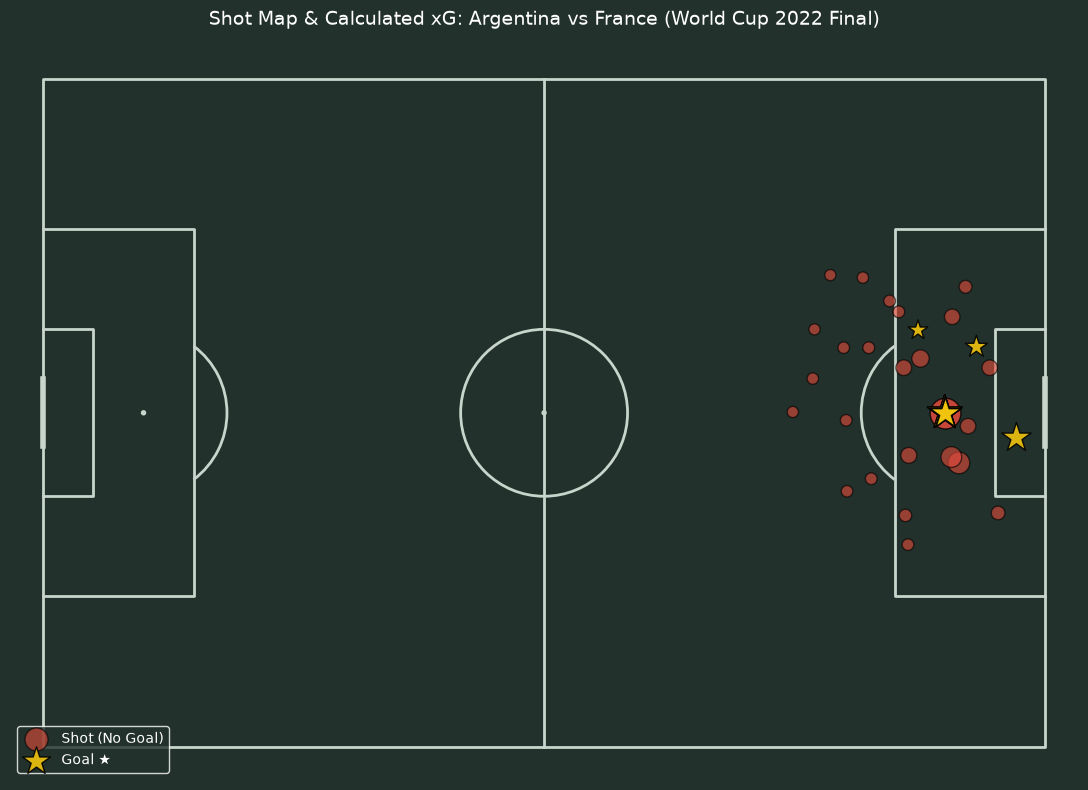

In [16]:
# Cell 8: Calculate xG for a specific match (Argentina vs France) and draw a Shot Map using mplsoccer

from mplsoccer import Pitch

# 1. Find the match_id for the World Cup Final (Argentina vs France)
final_match = matches[(matches['home_team'] == 'Argentina') & (matches['away_team'] == 'France')].iloc[0]
final_match_id = final_match['match_id']

# 2. Filter shots for this specific match
match_shots = shots[shots['match_id'] == final_match_id].copy()

# 3. Calculate distance and angle for this match's shots
match_shots['x'] = match_shots['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
match_shots['y'] = match_shots['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)
match_shots['distance'] = np.sqrt((120 - match_shots['x'])**2 + (40 - match_shots['y'])**2)

dx = 120 - match_shots['x']
dy1 = 36 - match_shots['y']
dy2 = 44 - match_shots['y']
match_shots['angle_degrees'] = np.degrees(np.abs(np.arctan2(dy2, dx) - np.arctan2(dy1, dx)))

match_shots['is_header'] = (match_shots['shot_body_part'] == 'Head').astype(int)
match_shots['is_open_play'] = (match_shots['shot_type'] == 'Open Play').astype(int)
match_shots['is_goal'] = (match_shots['shot_outcome'] == 'Goal').astype(int)

# 4. Predict xG values using our winning model
X_match = match_shots[['distance', 'angle_degrees', 'is_header', 'is_open_play']]
match_shots['calculated_xg'] = winning_model.predict_proba(X_match)[:, 1]

# 5. Draw the pitch using mplsoccer
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(12, 8))

# Separate goals and non-goals
goals = match_shots[match_shots['is_goal'] == 1]
non_goals = match_shots[match_shots['is_goal'] == 0]

# Plot non-goals (red circles, sized by calculated xG)
pitch.scatter(non_goals['x'], non_goals['y'], s=non_goals['calculated_xg'] * 800 + 50,
              c='#e74c3c', alpha=0.6, edgecolors='black', ax=ax, label='Shot (No Goal)')

# Plot goals (gold stars/circles, sized by calculated xG)
pitch.scatter(goals['x'], goals['y'], s=goals['calculated_xg'] * 800 + 100,
              c='#f1c40f', marker='*', edgecolors='black', alpha=0.9, ax=ax, label='Goal ★')

# Add titles and legend
plt.title(f"Shot Map & Calculated xG: Argentina vs France (World Cup 2022 Final)", fontsize=14, color='white', pad=15)
plt.legend(loc='lower left', labelcolor='white', facecolor='#22312b', edgecolor='white')
fig.set_facecolor('#22312b')

print(f"Total shots in Final: {len(match_shots)} | Total goals: {len(goals)}")
plt.show()